In [1]:

import sys
# sys.path.append(parent_dir)
import os
# os.chdir('/home/gaochi/OurDataset/')
from torch_geometric.datasets import CitationFull
from torch_geometric.datasets import ICEWS18
from ogb.linkproppred import LinkPropPredDataset

# collab = OGBLCollabDataset("/home/gaochi/OurDataset/") # collab.data.edge_index: (2, N)
# print(collab)

Disabling PyTorch because PyTorch >= 2.1 is required but found 1.13.0
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
import torch
from collections import Counter
from typing import Optional

def check_basis(edges: torch.Tensor) -> str:
    """
    检查 edges 形状是否为 (N, 2), type 是否为 int64, 且 N > 0
    """
    assert edges.ndim == 2, "edges must be a 2D tensor"
    assert edges.shape[1] == 2, "edges must have shape (N, 2)"
    assert edges.dtype == torch.int64, "edges must be of type int64"
    assert edges.shape[0] > 0, "edges must have N > 0"
    assert torch.all(edges >= 0), "edges must not contain -1"
    return "基本性质没问题"


def check_nodes_superset(tar_edges: torch.Tensor, oth_edges: torch.Tensor) -> str:
    """
    检查 tar_edges 的节点集合是否是 oth_edges 节点集合的超集。
    输入:
        tar_edges: (N, 2) 的 torch.Tensor
        oth_edges: (M, 2) 的 torch.Tensor
    输出:
        True  若 tar_edges.nodes 是 oth_edges.nodes 的超集
        False 否则
    """
    # 转为 list 以兼容 torch/numpy
    tar_nodes = torch.unique(tar_edges.flatten()).tolist()
    tar_nodes_set = set(tar_nodes)

    oth_nodes = torch.unique(oth_edges.flatten()).tolist()
    oth_nodes_set = set(oth_nodes)
    
    result = tar_nodes_set.issuperset(oth_nodes_set)
    assert result, "tar_edges 的节点集合不是 oth_edges 的超集"
    return "确为超集无误"

def check_nodes_feat_consistency(ori_nodes_feat: torch.Tensor, nodes_feat: torch.Tensor) -> str:
    """
    检查 ori_nodes_feat 和 nodes_feat 的一致性
    输入:
        ori_nodes_feat: 原始节点特征 (N, D)
        nodes_feat: 处理后的节点特征 (M, D)
    输出:
        True  若 ori_nodes_feat 和 nodes_feat 一致
        False 否则
    """
    if ori_nodes_feat is None or nodes_feat is None:
        return ori_nodes_feat is None and nodes_feat is None
    
    assert ori_nodes_feat.shape[0] == nodes_feat.shape[0], "节点数量不一致"
    assert ori_nodes_feat.shape[1] == nodes_feat.shape[1], "节点特征的维度不一致"
    
    # 检查每个节点的特征是否一致
    minus_one_mask = (nodes_feat == -1).all(dim=1) # 如果某个节点的节点特征全为 -1，可忽略这一节点
    equal_mask = (ori_nodes_feat == nodes_feat).all(dim=1)
    final_check = minus_one_mask | equal_mask
    
    # 要么节点可忽略，要么节点特征一致
    result = torch.all(final_check)
    assert result, "节点特征不一致"
    return "节点特征一致"

def check_edges_nointersection(tar_edges: torch.Tensor, oth_edges: torch.Tensor) -> str:
    """
    检查 tar_edges 和 oth_edges 是否有交集
    输入:
        tar_edges: (N, 2) 的 torch.Tensor
        oth_edges: (M, 2) 的 torch.Tensor
    输出:
        True  若 tar_edges 和 oth_edges 没有交集
        False 否则
    """
    # 转为 list 以兼容 torch/numpy
    tar_set = set(map(tuple, tar_edges.tolist()))
    oth_set = set(map(tuple, oth_edges.tolist()))

    is_intersection = len(tar_set.intersection(oth_set)) == 0
    ratio_in_tar = len(tar_set.intersection(oth_set)) / len(tar_set) if len(tar_set) > 0 else 0
    ratio_in_oth = len(tar_set.intersection(oth_set)) / len(oth_set) if len(oth_set) > 0 else 0
    print(f"tar_edges 和 oth_edges 的交集比例: {ratio_in_tar:.8%} in tar, {ratio_in_oth:.8%} in oth")
    
    assert ratio_in_tar < 0.01 and ratio_in_oth < 0.01, "tar_edges 和 oth_edges 有过多交集"
    return "边交集满足条件"

def check_edges_superset(tar_edges: torch.Tensor, oth_edges: torch.Tensor) -> str:
    """
    检查 tar_edges 的边集合是否是 oth_edges 边集合的超集。
    输入:
        tar_edges: (N, 2) 的 torch.Tensor
        oth_edges: (M, 2) 的 torch.Tensor
    输出:
        True  若 tar_edges 是 oth_edges 的超集
        False 否则
    """
    # 转为 list 以兼容 torch/numpy
    tar_set = set(map(tuple, tar_edges.tolist()))
    oth_set = set(map(tuple, oth_edges.tolist()))
    
    result = tar_set.issuperset(oth_set)
    assert result, "tar_edges 的边集合不是 oth_edges 的超集"
    return "确为超集无误"

def check_edges_equal(tar_edges: torch.Tensor, oth_edges: torch.Tensor) -> str:
    """
    检查 tar_edges 和 oth_edges 是否完全相同
    输入:
        tar_edges: (N, 2) 的 torch.Tensor
        oth_edges: (M, 2) 的 torch.Tensor
    输出:
        True  若 tar_edges 和 oth_edges 完全相同
        False 否则
    """
    assert tar_edges.shape == oth_edges.shape, "tar_edges 和 oth_edges 的形状不一致"
    
    # 转为 list 以兼容 torch/numpy
    tar_set = set(map(tuple, tar_edges.tolist()))
    oth_set = set(map(tuple, oth_edges.tolist()))
    
    result = tar_set == oth_set
    assert result, "tar_edges 和 oth_edges 不完全相同"
    return "边完全相同无误"

def check_degree_distribution(edges: torch.Tensor) -> str:
    """
    检查并打印：
      - 入度为 0 的点的占比
      - 出度为 0 的点的占比
      - 入度和出度均为 0 的点的占比
    输入:
        edges: (N, 2) 的 torch.Tensor, 每行 (src, dst)
    输出:
        返回包含三项占比的字符串
    """
    assert edges.ndim == 2 and edges.shape[1] == 2, "edges must be a (N,2) tensor"
    assert edges.dtype == torch.int64, "edges must be of type int64"
    assert edges.numel() > 0, "edges must not be empty"
    assert torch.all(edges >= 0), "edges must not contain negative node ids"

    # 确保在 CPU 上进行 bincount 操作
    src = edges[:, 0].to(torch.int64).cpu()
    dst = edges[:, 1].to(torch.int64).cpu()

    max_idx = int(torch.max(edges).item())
    num_nodes = max_idx + 1  # 假定节点 id 范围为 [0, max_idx]

    out_deg = torch.bincount(src, minlength=num_nodes)
    in_deg = torch.bincount(dst, minlength=num_nodes)

    zero_in = int((in_deg == 0).sum().item())
    zero_out = int((out_deg == 0).sum().item())
    zero_both = int(((in_deg == 0) & (out_deg == 0)).sum().item())

    ratio_in = zero_in / num_nodes
    ratio_out = zero_out / num_nodes
    ratio_both = zero_both / num_nodes

    print(f"入度为0的节点: {zero_in}/{num_nodes} ({ratio_in:.8%})")
    print(f"出度为0的节点: {zero_out}/{num_nodes} ({ratio_out:.8%})")
    print(f"入度&出度均为0的节点: {zero_both}/{num_nodes} ({ratio_both:.8%})")

    return f"入度0: {ratio_in:.8%}, 出度0: {ratio_out:.8%}, 入出度均0: {ratio_both:.8%}"

import networkx as nx
import matplotlib.pyplot as plt

def check_connected_components(edges: torch.Tensor, plot: bool = True) -> int:
    """
    检查无向连通分量数量，并可绘制各连通分量大小分布直方图。
    “连通”定义为：只要节点之间存在任意方向的边即可视为相连。

    参数:
        edges: torch.Tensor, 形状 (N, 2)，每行 (src, dst)
        plot : bool, 是否绘制连通分量大小分布直方图

    返回:
        连通分量的数量
    """
    assert edges.ndim == 2 and edges.shape[1] == 2, "edges must be a (N,2) tensor"
    assert edges.dtype == torch.int64, "edges must be of type int64"
    assert edges.numel() > 0, "edges must not be empty"
    assert torch.all(edges >= 0), "edges must not contain negative node ids"

    # 转换为无向边集合，去重
    src = edges[:, 0].cpu().tolist()
    dst = edges[:, 1].cpu().tolist()
    edge_list = list({tuple(sorted((int(u), int(v)))) for u, v in zip(src, dst) if u != v})

    # 构建无向图
    G = nx.Graph()
    G.add_edges_from(edge_list)

    # 计算连通分量
    components = list(nx.connected_components(G))
    comp_sizes = [len(c) for c in components]
    num_components = len(components)

    print(f"连通分量数量: {num_components}")
    print(f"最大分量大小: {max(comp_sizes)}")
    print(f"最小分量大小: {min(comp_sizes)}")
    print(f"平均分量大小: {sum(comp_sizes)/num_components:.2f}")

    # 绘制直方图
    if plot:
        plt.figure(figsize=(6,4))
        plt.hist(comp_sizes, bins=50, color='steelblue', edgecolor='black')
        plt.xlabel("size")
        plt.ylabel("num")
        plt.yscale("log")
        plt.title("distribution of connected component sizes")
        plt.tight_layout()
        plt.show()

    return num_components


def check_all_properties(
    ori_edges: torch.Tensor, ori_feats: Optional[torch.Tensor],
    train_pos: torch.Tensor, test_pos: torch.Tensor, test_neg: torch.Tensor,
    nodes_feat: Optional[torch.Tensor], 
    uniq_nodes: torch.Tensor,
    remap: torch.Tensor
):
    assert type(nodes_feat) == type(ori_feats), f"nodes_feat and ori_feats must be of the same type, None or torch.Tensor, but we get {type(nodes_feat)} and {type(ori_feats)}"
    ## 检查入度和出度
    print("检查 train_pos 的度分布:")
    check_degree_distribution(train_pos)
    # print("检查 test_pos 的度分布:")
    # check_degree_distribution(test_pos)
    print("检查 train_pos 的连通分量:")
    check_connected_components(train_pos)

    # # 检查形状和类型
    print(f"train_pos 形状和类型检查: {check_basis(train_pos)}\n")
    print(f"test_pos 形状和类型检查: {check_basis(test_pos)}\n")
    print(f"test_neg 形状和类型检查: {check_basis(test_neg)}\n")

    # # 检查训练集、测试集的内部属性一致性
    ## 检查 train nodes 是否是 test nodes 的超集
    print(f"train nodes 是 test nodes 的超集检查: {check_nodes_superset(train_pos, test_pos)}\n")
    ## 检查 train edges 和 test edges(_neg) 是否有交集
    print(f"train edges 和 test edges 没有交集检查: {check_edges_nointersection(train_pos, test_pos)}\n")
    print(f"train edges 和 test edges_neg 没有交集检查: {check_edges_nointersection(train_pos, test_neg)}\n")
    ## 检查 test edges 和 test edges_neg 是否有交集
    print(f"test edges 和 test edges_neg 没有交集检查: {check_edges_nointersection(test_pos, test_neg)}\n")

    # # 检查训练、测试集与原本数据集的一致性
    # remap_train_pos = uniq_nodes[train_pos.clone()]
    # remap_test_pos = uniq_nodes[test_pos.clone()]
    # remap_test_neg = uniq_nodes[test_neg.clone()]
    
    # ## 检查节点特征一致性
    # if ori_feats is not None and nodes_feat is not None:
    #     remap_nodes_feat = - torch.ones_like(ori_feats)
    #     remap_nodes_feat[uniq_nodes] = nodes_feat
    #     print(f"节点特征一致性检查: {check_nodes_feat_consistency(ori_feats, remap_nodes_feat)}\n")

    # ## 检查 remap 后的 train_pos / test_pos 是否是原始集合的子集，而 test_neg 是否与原始集合无交集
    # print(f"remap 后的 train_pos 是 ori_edges 的子集检查: {check_edges_superset(ori_edges, remap_train_pos)}\n")
    # print(f"remap 后的 test_pos 是 ori_edges 的子集检查: {check_edges_superset(ori_edges, remap_test_pos)}\n")
    # print(f"remap 后的 test_neg 和 ori_edges 的是否相交: {check_edges_nointersection(remap_test_neg, ori_edges)}\n")
    


def load_icews18(root):
    train_dataset = ICEWS18(root, split='train')
    val_dataset = ICEWS18(root, split='val')
    test_dataset = ICEWS18(root, split='test')
    
    dataset = train_dataset
    dataset.data.sub = torch.cat([train_dataset.data.sub, val_dataset.data.sub, test_dataset.data.sub], dim=0)
    dataset.data.obj = torch.cat([train_dataset.data.obj, val_dataset.data.obj, test_dataset.data.obj], dim=0)
    dataset.data.rel = torch.cat([train_dataset.data.rel, val_dataset.data.rel, test_dataset.data.rel], dim=0)
    dataset.data.t = torch.cat([train_dataset.data.t, val_dataset.data.t, test_dataset.data.t], dim=0)
        
    edge_index = torch.tensor(torch.zeros((dataset.data.sub.shape[0], 2)), dtype=torch.int64)
    for i, (u, v) in enumerate(zip(dataset.data.sub, dataset.data.obj)):
        edge_index[i][0] = u
        edge_index[i][1] = v
    dataset.data.edge_index = edge_index.t()
    return dataset

def load_txt(root, ratio):
    splits = ['train_pos', 'test_pos', 'test_neg']
    all_edges = {}
    for split in splits:
        with open(os.path.join(root, f"split_{ratio}", f'{split}.txt'), 'r') as f:
            edges = [list(map(int, line.strip().split()))[:2] for line in f.readlines()]
            edges = torch.tensor(edges, dtype=torch.int64) # (N, 2)
            all_edges[split] = edges
    return all_edges


/tmp/ipykernel_596261/1039825107.py:32: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for name, path in tqdm_notebook(dataset_paths.items(), desc='Processing datasets'):


Processing datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Processing ogbl_citation2 dataset with ratio 0.02...
data keys:
train.edge
test.edge
test.edge_neg
valid.edge
valid.edge_neg
x
remap
uniq_nodes
test_deg
Processing ogbl_citation2 dataset for .pt format...
检查 train_pos 的度分布:
入度为0的节点: 1476771/2436842 (60.60183631%)
出度为0的节点: 10305/2436842 (0.42288339%)
入度&出度均为0的节点: 0/2436842 (0.00000000%)
检查 train_pos 的连通分量:
连通分量数量: 1
最大分量大小: 2436842
最小分量大小: 2436842
平均分量大小: 2436842.00


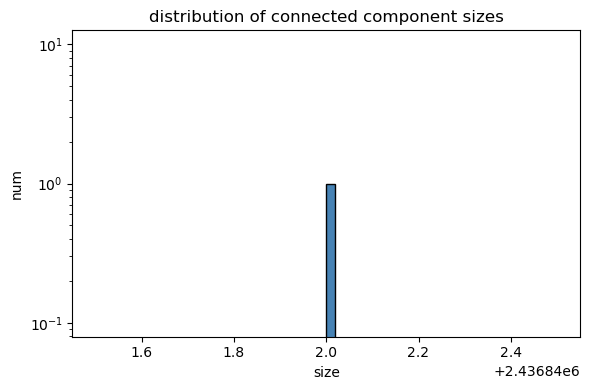

train_pos 形状和类型检查: 基本性质没问题

test_pos 形状和类型检查: 基本性质没问题

test_neg 形状和类型检查: 基本性质没问题

train nodes 是 test nodes 的超集检查: 确为超集无误

tar_edges 和 oth_edges 的交集比例: 0.00000000% in tar, 0.00000000% in oth
train edges 和 test edges 没有交集检查: 边交集满足条件

tar_edges 和 oth_edges 的交集比例: 0.00015816% in tar, 0.00005790% in oth
train edges 和 test edges_neg 没有交集检查: 边交集满足条件

tar_edges 和 oth_edges 的交集比例: 0.00000000% in tar, 0.00000000% in oth
test edges 和 test edges_neg 没有交集检查: 边交集满足条件



In [4]:
import torch
from tqdm import tqdm_notebook
import numpy as np

dataset_paths = {
    # 'cora_ml': '/home/gaochi/leaf_matching/datasets/cora_ml/split',
    # 'citeseer': '/home/gaochi/leaf_matching/datasets/citeseer/split',
    # 'cora': '/home/gaochi/leaf_matching/datasets/cora/split',
    # 'pubmed': '/home/gaochi/leaf_matching/datasets/pubmed/split',
    # 'icews18': '/home/gaochi/leaf_matching/datasets/icews18/split',
    # 'twitter': '/home/gaochi/leaf_matching/datasets/twitter/split',
    'ogbl_citation2': '/home/gaochi/leaf_matching/datasets/ogbl_citation2/split',
}
dataset_types = {
    'cora_ml': 'efficiency',
    'citeseer': 'efficiency',
    'cora': 'efficiency',
    'pubmed': 'efficiency',
    'icews18': 'efficiency',
    'twitter': 'practicality',
    'ogbl_citation2': 'tmp',
}
tar_splits1 = ['train', 'valid', 'valid', 'test', 'test']
tar_splits2 = ['edge', 'edge', 'edge_neg', 'edge', 'edge_neg']
ratio_type = {
    'efficiency': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'practicality': [0.02],
    'both': [ 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'tmp': [0.02]
}

for name, path in tqdm_notebook(dataset_paths.items(), desc='Processing datasets'):
    for ratio in ratio_type[dataset_types[name]]:
        print(f"Processing {name} dataset with ratio {ratio}...")
        def print_nested_keys(d, prefix=''):
            if isinstance(d, dict):
                for k, v in d.items():
                    print_nested_keys(v, prefix + str(k) + '.')
            else:
                print(prefix[:-1])  # Remove the trailing dot

        data = torch.load(os.path.join(path, f'split_dict_{ratio}.pt'))
        
        print("data keys:")
        print_nested_keys(data)
        if name == 'cora_ml':
            ori_dataset = CitationFull('/home/gaochi/leaf_matching/datasets', name='cora_ml', to_undirected=False)
            edges = torch.tensor(ori_dataset.data.edge_index).long()
            nodes_feat = None
        elif name == 'citeseer':
            ori_dataset = CitationFull('/home/gaochi/leaf_matching/datasets', name='citeseer', to_undirected=False)
            edges = torch.tensor(ori_dataset.data.edge_index).long()
            nodes_feat = None
        elif name == 'pubmed':
            ori_dataset = CitationFull('/home/gaochi/leaf_matching/datasets', name='pubmed', to_undirected=False)
            edges = torch.tensor(ori_dataset.data.edge_index).long()
            nodes_feat = None
        elif name == 'cora':
            ori_dataset = CitationFull('/home/gaochi/leaf_matching/datasets', name='cora', to_undirected=False)
            edges = torch.tensor(ori_dataset.data.edge_index).long()
            nodes_feat = None
        elif name == 'icews18':
            ori_dataset = load_icews18('/home/gaochi/leaf_matching/datasets/icews18')
            edges = torch.tensor(ori_dataset.data.edge_index).long()
            nodes_feat = None
        elif name == 'twitter':
            edges = torch.tensor(np.load('/home/gaochi/leaf_matching/datasets/twitter/edges.npy')).long()
            nodes_feat = torch.tensor(np.load('/home/gaochi/leaf_matching/datasets/twitter/features_top512.npy')).float()
        elif name == 'ogbl_citation2':
            ori_dataset = LinkPropPredDataset(root="/home/gaochi/leaf_matching/datasets", name='ogbl-citation2')
            edges = torch.tensor(ori_dataset.graph['edge_index']).long()
            nodes_feat = torch.tensor(ori_dataset.graph['node_feat']).float()

        assert edges is not None and isinstance(edges, torch.Tensor) and edges.shape[0] == 2 and edges.shape[1] > 1000, f"Edges for {name} dataset are not valid: {edges.shape} or not valid type: {type(edges)}"
                    
        ori_edges = edges.t() # (E, 2)
        
        print(f'Processing {name} dataset for .pt format...')
        check_all_properties(
            ori_edges, nodes_feat if 'nodes_feat' in locals() else None,
            data['train']['edge'],
            data['test']['edge'],
            data['test']['edge_neg'],
            data['x'] ,
            data['uniq_nodes'],
            data['remap']
        )
        
        if dataset_types[name] == 'efficiency':
            # 处理 txt 格式
            print(f'Processing {name} dataset for .txt format...')
            all_edges = load_txt(path, ratio)
            txt_train_pos, txt_test_pos, txt_test_neg = all_edges['train_pos'], all_edges['test_pos'], all_edges['test_neg']
            print(f"train pos 是否完全相同：{check_edges_equal(data['train']['edge'], txt_train_pos)}")
            print(f"test pos 是否完全相同：{check_edges_equal(data['test']['edge'], txt_test_pos)}")
            print(f"test neg 是否完全相同：{check_edges_equal(data['test']['edge_neg'], txt_test_neg)}")